In [22]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cudaq
import sys
import os
import shutil
import faulthandler
from scipy.linalg import expm
from math import sqrt
from tqdm import tqdm
import torch
from typing import List, Tuple
sys.path.append(os.path.abspath(".."))
from Utils.qaoaCUDAQ import po_normalize, ret_cov_to_QUBO, qubo_to_ising, process_ansatz_values, kernel_flipped, all_state_to_return, find_budget

In [23]:
e = 0
N_ASSETS = 3
TARGET_QUBIT_IN = 2
q = 0
lamb = 0

device = torch.device("cuda")
DUPLICATE_ASSET = False
min_P, max_P = 108, 216

In [24]:
data_cov_pd = pd.read_csv("../dataset/top_50_us_stocks_data_20250526_011226_covariance.csv")
data_ret_p_pd = pd.read_csv("../dataset/top_50_us_stocks_returns_price.csv")

data_ret_p_pd = data_ret_p_pd[(data_ret_p_pd["Price"] > min_P) & (data_ret_p_pd["Price"] < max_P)]
data_cov_pd = data_cov_pd.loc[data_cov_pd["Ticker"].isin(data_ret_p_pd["Ticker"])].reset_index(drop=True)
data_cov_pd = data_cov_pd[["Ticker"] + data_cov_pd["Ticker"].tolist()]

In [25]:
np.random.seed(911 + 991 * e + 997 * N_ASSETS)
state = np.random.get_state()
# asset_idx = np.random.choice(data_cov_pd.shape[0], max(TARGET_ASSET), replace=False)
asset_idx = np.random.choice(data_cov_pd.shape[0], N_ASSETS, replace=DUPLICATE_ASSET)
# print(asset_idx)
# asset_idx = np.array([0, 18, 27, 32, 41])
# data_cov = data_cov_pd.drop("Ticker", axis=1)
data_cov = data_cov_pd.drop("Ticker", axis=1).to_numpy()[asset_idx, :][:, asset_idx]
stock_names = data_ret_p_pd["Company_Name"].to_numpy()[asset_idx]
# print("Selected Stocks: ", stock_names)
data_ret_p = data_ret_p_pd.drop("Ticker", axis=1)
# print(data_ret_p.index[asset_idx].to_numpy())
asset_idx_raw = data_ret_p.index[asset_idx].to_numpy()
data_ret_p = data_ret_p.drop("Company_Name", axis=1).to_numpy()[asset_idx, :]

data_ret = data_ret_p[:, 0]
data_p = data_ret_p[:, 1]
print("Selected Stocks: ", stock_names)
print("Selected Stocks Price: ", data_p)
print("Selected Stocks Return: ", data_ret)

Selected Stocks:  ['Philip Morris International Inc.' 'Abbott Laboratories' 'Broadcom Inc.']
Selected Stocks Price:  [158.72999573 132.0383606  167.42999268]
Selected Stocks Return:  [0.00060737 0.00060593 0.00142008]


In [26]:
np.random.set_state(state)
weighted = np.random.uniform(0, 1)
B_mi, B_ma = find_budget(TARGET_QUBIT_IN * N_ASSETS, data_p, min_P, max_P, min_mix_mode=True)
B = B_mi * weighted + B_ma * (1 - weighted)

P = data_p[:N_ASSETS]
ret = data_ret[:N_ASSETS]
cov = data_cov[:N_ASSETS, :N_ASSETS]
P_bb, ret_bb, cov_bb, n_qubit, n_max, C = po_normalize(B, P, ret, cov)
TARGET_QUBIT = n_qubit

# QUBOs of MAX PROBLEM
QU = ret_cov_to_QUBO(ret_bb, cov_bb, P_bb, lamb, q)
QU_lamb = ret_cov_to_QUBO(np.zeros_like(ret_bb), np.zeros_like(cov_bb), P_bb, lamb, 0.0)
QU_eval = ret_cov_to_QUBO(ret_bb, cov_bb, P_bb, 0.0, q)
QU_return = ret_cov_to_QUBO(ret_bb, np.zeros_like(cov_bb), np.zeros_like(P_bb), 0.0, 0.0)
QU_risk = ret_cov_to_QUBO(np.zeros_like(ret_bb), cov_bb, np.zeros_like(P_bb), 0.0, q)

# Hamiltonians of MIN PROBLEM
H_ansatz = -qubo_to_ising(QU, lamb).canonicalize()
H_lamb = -qubo_to_ising(QU_lamb, lamb).canonicalize()
H_eval = -qubo_to_ising(QU_eval, 0.0).canonicalize()
H_return = -qubo_to_ising(QU_return, 0.0).canonicalize()
H_risk = -qubo_to_ising(QU_risk, 0.0).canonicalize()

idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use = process_ansatz_values(H_ansatz)

In [27]:
n_b = 1<<TARGET_QUBIT
H = H_ansatz.to_matrix()
print("Is Hermitian:", (H == np.conj(H).T).all())
eigvals, eigvecs = np.linalg.eigh(H)

eigvals = np.random.rand(n_b) * 3
eigvals = np.sort(eigvals)
# eigvals = eigvals - eigvals[0]
# eigvals[1:] += 1

H = eigvecs @ np.diag(eigvals) @ eigvecs.T
# print("Modified H:\n", H)

for i in range(len(eigvals)):
    print(f"Eigenvalue {i}: {eigvals[i]}")
    print(f"Eigenvector {i}:\n{eigvecs[:, i]}\n")

ground_state = eigvecs[:, 0]
print("Ground state:\n", ground_state)

# print(np.linalg.eigh(H))
# print(np.linalg.eig(H))

# b = np.random.rand(n_b)
b = np.ones(n_b)
b = b / np.linalg.norm(b)
print("Vector b:\n", b)

spectral_gap = eigvals[1] - eigvals[0]
spectral_radius = max(abs(eigvals))
print("\nSpectral gap:", spectral_gap)
print("Spectral radius:", spectral_radius)

ss = spectral_gap / (12 * spectral_radius**3)
F0 = abs(b @ ground_state)**2
print("F0:", F0)
q = 1 - ss * F0 * spectral_gap
print("q:", q)
print("Recommended step size (s):", ss)
assert spectral_radius > 1

Is Hermitian: True
Eigenvalue 0: 0.026456695199172486
Eigenvector 0:
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 1.+0.j]

Eigenvalue 1: 0.0762567911048947
Eigenvector 1:
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j


In [28]:
idx_t = np.argmax(np.abs(ground_state))
idx_t_bin = bin(idx_t)[2:].zfill(TARGET_QUBIT)
print(f"Index of target state (binary): {idx_t_bin} ({idx_t})")

Index of target state (binary): 111111 (63)


In [29]:
def commutator(A, B):
    return A @ B - B @ A

In [30]:
assert False

AssertionError: 

## EQ 1

In [62]:
# tau = 200
# tau = 0.2
N = 60000
tau = ss * N
tau = 1
# N = 100

print("tau:", tau)


# e^(-tau H)
exp_H = expm(-tau * H)
print("Exponential of -tau * H:\n", exp_H)
result = exp_H @ b
result = result / np.linalg.norm(result)
print("Fidelity with ground state:", abs(result @ ground_state)**2)

print("Result of normed exp(-tau * H) @ b:", result)
# print("Result of normed exp(-tau * H) @ b:", np.round(result))

tau: 1
Exponential of -tau * H:
 [[0.05149539+0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.05722323+0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.06679262+0.j ... 0.        +0.j
  0.        +0.j 0.        +0.j]
 ...
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.79969468+0.j
  0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.8793305 +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j ... 0.        +0.j
  0.        +0.j 0.97389022+0.j]]
Fidelity with ground state: 0.07560255702150062
Result of normed exp(-tau * H) @ b: [0.01453873+0.j 0.01615588+0.j 0.01885761+0.j 0.02314036+0.j
 0.0146439 +0.j 0.01818996+0.j 0.02289783+0.j 0.03650029+0.j
 0.01634145+0.j 0.02277919+0.j 0.03083401+0.j 0.04487481+0.j
 0.02200691+0.j 0.02856658+0.j 0.04382396+0.j 0.05742436+0.j
 0.02073976+0.j 0.02724162+0.j 0.042294

## EQ 8

In [63]:
s = tau / N

s = 1
N = 1

bb = b.copy()
bb_t = torch.tensor(bb, device=device, dtype=torch.complex64)
H_t = torch.tensor(H, device=device, dtype=torch.complex64)
for i in tqdm(range(N)):
    densi = torch.outer(bb_t, bb_t)
    # Q = torch.matrix_exp(s * (densi @ H_t - H_t @ densi))
    Q = torch.matrix_exp(s * commutator(densi, H_t))
    bb_t = Q @ bb_t
bb = bb_t.cpu().numpy()
result = bb
print("Fidelity with ground state:", abs(result @ ground_state)**2)
print("Result:", result)
print("Norm:", np.linalg.norm(result))
# print(np.round(result))
print(np.abs(result)**2)

100%|██████████| 1/1 [00:00<00:00,  5.98it/s]

Fidelity with ground state: 0.052216203699092745
Result: [-0.09444049+0.j -0.08285441+0.j -0.06586748+0.j -0.0433846 +0.j
 -0.09364871+0.j -0.06982736+0.j -0.04454203+0.j  0.00668044+0.j
 -0.08159986+0.j -0.04511271+0.j -0.01185216+0.j  0.02937144+0.j
 -0.04890171+0.j -0.02024285+0.j  0.02676839+0.j  0.05646055+0.j
 -0.05541641+0.j -0.02545998+0.j  0.02286524+0.j  0.05622535+0.j
 -0.03484465+0.j  0.02197312+0.j  0.05123086+0.j  0.08243047+0.j
  0.01571755+0.j  0.04730503+0.j  0.07786583+0.j  0.1144604 +0.j
  0.04372144+0.j  0.06793298+0.j  0.10053462+0.j  0.14875433+0.j
  0.04332795+0.j  0.06593665+0.j  0.09932831+0.j  0.13825019+0.j
  0.05907743+0.j  0.08715031+0.j  0.13336983+0.j  0.16100836+0.j
  0.0837402 +0.j  0.12230911+0.j  0.16052984+0.j  0.18476298+0.j
  0.11679687+0.j  0.15962881+0.j  0.18296051+0.j  0.20608611+0.j
  0.11606394+0.j  0.15390944+0.j  0.18041253+0.j  0.1959459 +0.j
  0.15058103+0.j  0.16642906+0.j  0.19473773+0.j  0.21453547+0.j
  0.16571985+0.j  0.19361924+0.j 

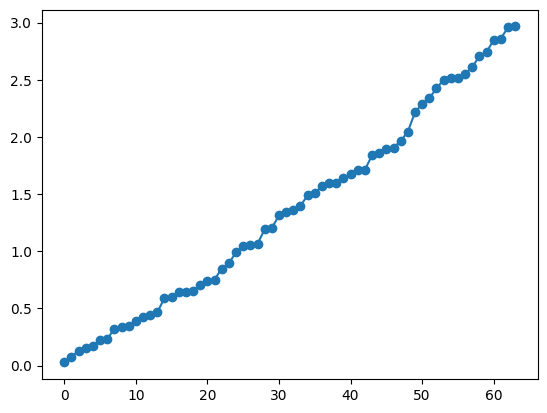

In [75]:
plt.plot(eigvals, marker='o')

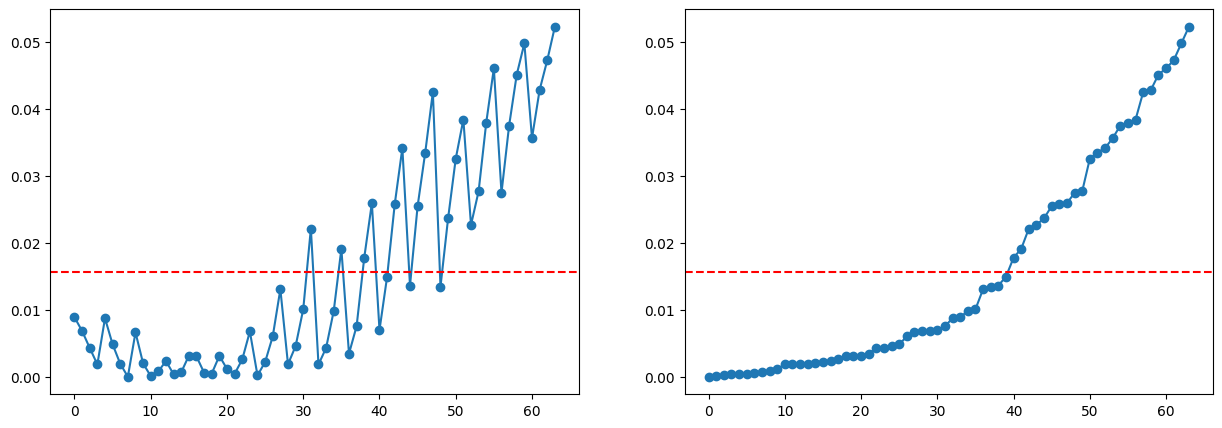

In [72]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(abs(result)**2, marker='o')
plt.axhline(y=1/(1<<TARGET_QUBIT), color='r', linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(sorted(abs(result)**2), marker='o')
plt.axhline(y=1/(1<<TARGET_QUBIT), color='r', linestyle='--')

|e^ia| = 1
|e^(a + ib)| = e^a

# EQ 12


e^(iPt) = I + (e^(it) - 1)P

In [80]:
s = tau / N

s = 1
N = 2

bb = b.copy()
bb_t = torch.tensor(bb, device=device, dtype=torch.complex64)
H_t = torch.tensor(H, device=device, dtype=torch.complex64)
ground_state_t = torch.tensor(ground_state, device=device, dtype=torch.complex64)
E1 = torch.matrix_exp(-1j*sqrt(s)*H_t)
E3 = torch.matrix_exp(1j*sqrt(s)*H_t)
E1_dagger = torch.adjoint(E1)
for i in tqdm(range(N)):
    densi = torch.outer(bb_t, bb_t)
    E2 = torch.matrix_exp(1j*sqrt(s)*densi)
    # E2 = torch.eye(H_t.shape[0], device=device, dtype=torch.complex64) + (np.exp(1j*sqrt(s)) - 1) * densi
    E2_dagger = torch.adjoint(E2)
    E321 = E3 @ E2 @ E1
    E321_dagger = torch.adjoint(E321)
    print("Trace of E2_dagger @ E2:", torch.trace(E2_dagger @ E2).item())
    eigvalss, eigvecss = torch.linalg.eig(E321)
    print("Eigenvalues of E321:", torch.sort(torch.abs(eigvalss)))
    bbb = bb_t.clone()
    bb_t = E321 @ bb_t
    if (i+1) % 1 == 0:
        F_k = abs(bb_t @ ground_state_t)**2
        print(f"iter {i+1}")
        print("norm of bb_t:", torch.norm(bb_t).item())
        print(f"F_{i+1}:", F_k.item())
        lower_bound = 1 - q**(i+1)
        print(f"Lower bound for F_{i+1}:", lower_bound)
        print()
    bb_t = bb_t / torch.norm(bb_t)
bb = bb_t.cpu().numpy()

print("Fidelity with ground state:", abs(bb @ ground_state)**2)
print("Result of DB-QITE:", bb)
print("Abs of DB-QITE result:", np.abs(bb) * np.sign(bb.real))
print("Norm of DB-QITE result:", np.linalg.norm(bb))

100%|██████████| 2/2 [00:00<00:00, 196.36it/s]

Trace of E2_dagger @ E2: (64.00004577636719+7.900682885697563e-10j)
Eigenvalues of E321: torch.return_types.sort(
values=tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], device='cuda:0'),
indices=tensor([ 2,  4, 24, 19, 23, 34, 27, 50, 60, 31, 36, 45, 63, 18, 10, 44, 52, 20,
        22, 28, 61, 62,  1,  5, 39, 41, 49, 30, 46, 53, 56, 57, 59,  6, 37, 40,
        51, 15, 35, 47, 48, 54, 17, 43, 55, 42,  9, 25, 26, 29, 58, 14, 11, 32,
        33, 21, 38,  0,  8, 16, 12, 

In [ ]:
print(torch.trace(E1 @ E3))
print(np.exp(-1j*sqrt(s)))

tensor(64.0000-7.6857e-08j, device='cuda:0')
(0.5403023058681398-0.8414709848078965j)


In [ ]:
print(s)

1


In [ ]:
# print(densi)
bbb = bbb / torch.norm(bbb)
print("Norm of bbb:", torch.norm(bbb).item())
densi = torch.outer(bbb, bbb)
# dd = torch.matrix_exp(1j*10*densi)
dd = torch.eye(H_t.shape[0], device=device, dtype=torch.complex64) + (np.exp(1j*10) - 1) * densi
dd_dagger = torch.adjoint(dd)
print(torch.trace(dd_dagger @ dd))
print(torch.diag(dd_dagger @ dd))

Norm of bbb: 1.0
tensor(66.4579+5.8931e-09j, device='cuda:0')
tensor([1.0077+2.9315e-10j, 1.0048+1.7296e-10j, 1.0015+7.5516e-11j,
        0.9997+6.1417e-12j, 1.0075-1.5758e-10j, 1.0021-3.2431e-11j,
        0.9997+1.6662e-11j, 1.0092+1.1779e-10j, 1.0045+1.0028e-10j,
        0.9997-1.4497e-11j, 1.0034-9.7188e-11j, 1.0192-1.9447e-10j,
        0.9998-1.1275e-11j, 1.0017-9.4905e-11j, 1.0179+2.0747e-10j,
        1.0339+5.7721e-10j, 1.0002+6.9596e-12j, 1.0008-1.2509e-11j,
        1.0160-2.7537e-10j, 1.0338+5.8828e-10j, 0.9999-4.6308e-11j,
        1.0156-8.2710e-13j, 1.0309-6.5759e-11j, 1.0483+3.3182e-10j,
        1.0128-1.0800e-10j, 1.0287+3.7486e-10j, 1.0459-7.7814e-10j,
        1.0625+9.0120e-10j, 1.0268-7.7223e-11j, 1.0404+7.2905e-10j,
        1.0571-2.8519e-10j, 1.0691+1.7706e-09j, 1.0265+8.9386e-11j,
        1.0393-4.9680e-10j, 1.0566+6.4726e-10j, 1.0682-1.2110e-09j,
        1.0354+8.5629e-10j, 1.0507+8.2483e-10j, 1.0675+7.2160e-10j,
        1.0687+1.9980e-10j, 1.0490+4.8018e-10j, 1.0649

In [ ]:
eig_valss, eig_vecss = torch.linalg.eig(dd)
print(abs(eig_valss))
print(eig_vecss[:, 1])

tensor([6.0007e-04, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00], device='cuda:0')
tensor([ 9.9356e-01+0.0000e+00j,  6.0936e-03+5.4710e-04j,
        -4.8683e-03-1.0041e-04j, -4.4686e-03+9.7803e-03j,
         9

In [ ]:
print(bbb)

tensor([0.0458-0.0506j, 0.0562-0.0207j, 0.0415+0.0263j, 0.0523+0.0646j,
        0.0574-0.0222j, 0.0428+0.0058j, 0.0520+0.0641j, 0.0431+0.0374j,
        0.0430+0.0048j, 0.0488+0.0565j, 0.0461+0.0488j, 0.0490-0.0106j,
        0.0473+0.0526j, 0.0485+0.0558j, 0.0453-0.0028j, 0.0584-0.0246j,
        0.0552-0.0195j, 0.0419+0.0296j, 0.0548+0.0698j, 0.0413+0.0195j,
        0.0421+0.0095j, 0.0540+0.0683j, 0.0425+0.0340j, 0.0532-0.0169j,
        0.0491+0.0573j, 0.0455+0.0471j, 0.0493-0.0111j, 0.0579-0.0270j,
        0.0465+0.0499j, 0.0455-0.0034j, 0.0584-0.0250j, 0.0438-0.0597j,
        0.0425+0.0343j, 0.0579+0.0756j, 0.0414+0.0163j, 0.0568-0.0215j,
        0.0601+0.0793j, 0.0424+0.0334j, 0.0547-0.0188j, 0.0498-0.0401j,
        0.0432+0.0379j, 0.0504-0.0129j, 0.0566-0.0291j, 0.0431-0.0718j,
        0.0482-0.0092j, 0.0584-0.0257j, 0.0438-0.0603j, 0.0516-0.1074j,
        0.0557+0.0717j, 0.0427+0.0062j, 0.0573-0.0222j, 0.0440-0.0585j,
        0.0416+0.0274j, 0.0553-0.0195j, 0.0483-0.0434j, 0.0456-0

In [43]:
k = 3
U = [None for _ in range(k+1)]
def conj(l):
    ll = [(a, b, -c) for (a, b, c) in l[::-1]]
    return ll

def dfs(n, i):
    if i == 0:
        return [("U", 0, 0)]
    if U[i] is not None:
        return U[i]
    U[i] = dfs(n, i-1) + [("H", i-1, -1)] + conj(dfs(n, i-1)) + [("D", i-1, 1)] + dfs(n, i-1) + [("H", i-1, 1)]
    return U[i]

In [44]:
dfs(k, k)
for i in range(k+1):
    print(f"U_{i}:", U[i])
# a = [('H', 0, 1), ('D', 0, -1)]
# print(conj(a))
type_l, tim_l, abs_l = zip(*U[k])
type_l = [0 if t == "H" else 1 if t == "D" else 2 for t in type_l]
tim_l = np.array(tim_l)
abs_l = np.array(abs_l)
type_l = np.array(type_l)

print("tim_l:", tim_l)
print("abs_l:", abs_l)
print("type_l:", type_l)

U_0: None
U_1: [('U', 0, 0), ('H', 0, -1), ('U', 0, 0), ('D', 0, 1), ('U', 0, 0), ('H', 0, 1)]
U_2: [('U', 0, 0), ('H', 0, -1), ('U', 0, 0), ('D', 0, 1), ('U', 0, 0), ('H', 0, 1), ('H', 1, -1), ('H', 0, -1), ('U', 0, 0), ('D', 0, -1), ('U', 0, 0), ('H', 0, 1), ('U', 0, 0), ('D', 1, 1), ('U', 0, 0), ('H', 0, -1), ('U', 0, 0), ('D', 0, 1), ('U', 0, 0), ('H', 0, 1), ('H', 1, 1)]
U_3: [('U', 0, 0), ('H', 0, -1), ('U', 0, 0), ('D', 0, 1), ('U', 0, 0), ('H', 0, 1), ('H', 1, -1), ('H', 0, -1), ('U', 0, 0), ('D', 0, -1), ('U', 0, 0), ('H', 0, 1), ('U', 0, 0), ('D', 1, 1), ('U', 0, 0), ('H', 0, -1), ('U', 0, 0), ('D', 0, 1), ('U', 0, 0), ('H', 0, 1), ('H', 1, 1), ('H', 2, -1), ('H', 1, -1), ('H', 0, -1), ('U', 0, 0), ('D', 0, -1), ('U', 0, 0), ('H', 0, 1), ('U', 0, 0), ('D', 1, -1), ('U', 0, 0), ('H', 0, -1), ('U', 0, 0), ('D', 0, 1), ('U', 0, 0), ('H', 0, 1), ('H', 1, 1), ('H', 0, -1), ('U', 0, 0), ('D', 0, -1), ('U', 0, 0), ('H', 0, 1), ('U', 0, 0), ('D', 2, 1), ('U', 0, 0), ('H', 0, -1), ('U

e^(iZt)
rz(t) = e^(-iZt/2)
rz(pi) = Z, rz(2pi) = I

In [45]:
@cudaq.kernel
def kernel_DB_QITE(step_size: List[float], qubit_count: int, idx_1: List[int], coeff_1: List[float], idx_2_a: List[int], idx_2_b: List[int], coeff_2: List[float], type_l: List[int], tim_l: List[int], abs_l: List[float]):
    qreg = cudaq.qvector(qubit_count)
    # h(qreg)

    for i in range(len(type_l)):
        # H
        if type_l[i] == 0:
            for j in range(len(idx_1)):
                rz(-2 * abs_l[i] * coeff_1[j] * np.sqrt(step_size[tim_l[i]]), qreg[idx_1[j]])
            for j in range(len(idx_2_a)):
                x.ctrl(qreg[idx_2_a[j]], qreg[idx_2_b[j]])
                rz(-2  * abs_l[i] * coeff_2[j] * np.sqrt(step_size[tim_l[i]]), qreg[idx_2_b[j]])
                x.ctrl(qreg[idx_2_a[j]], qreg[idx_2_b[j]])
        
        # D
        elif type_l[i] == 1:
            # h(qreg)
            # rz(-1 * abs_l[i] * step_size[tim_l[i]], qreg[qubit_count-1])
            # x.ctrl(qreg[0:qubit_count-1], qreg[qubit_count-1])
            # rz(-1 * abs_l[i] * step_size[tim_l[i]], qreg[qubit_count-1])
            # x.ctrl(qreg[0:qubit_count-1], qreg[qubit_count-1])
            # rz(2 * abs_l[i] * step_size[tim_l[i]], qreg[qubit_count-1])
            # h(qreg)

            ### I'M SORRY DEAR, BUT THIS IS NOT e^(i|u><u|) YOU'RE LOOKING FOR
            # h(qreg)
            x(qreg)
            rz.ctrl(1 * abs_l[i] * np.sqrt(step_size[tim_l[i]]), qreg[0:qubit_count-1], qreg[qubit_count-1])
            x(qreg)
            # h(qreg)

        # U
        elif type_l[i] == 2:
            h(qreg)

In [46]:
print(cudaq.draw(kernel_DB_QITE, [1.0]*k, TARGET_QUBIT, idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use, type_l, tim_l, abs_l))

     ╭───╮╭───────────────╮╭───╮╭───╮         ╭───╮╭───╮╭────────────────╮»
q0 : ┤ h ├┤ rz(0.0002034) ├┤ h ├┤ x ├────●────┤ x ├┤ h ├┤ rz(-0.0002034) ├»
     ├───┤├───────────────┤├───┤├───┤    │    ├───┤├───┤├────────────────┤»
q1 : ┤ h ├┤ rz(0.0004068) ├┤ h ├┤ x ├────●────┤ x ├┤ h ├┤ rz(-0.0004068) ├»
     ├───┤├───────────────┤├───┤├───┤    │    ├───┤├───┤├────────────────┤»
q2 : ┤ h ├┤ rz(0.0001688) ├┤ h ├┤ x ├────●────┤ x ├┤ h ├┤ rz(-0.0001688) ├»
     ├───┤├───────────────┤├───┤├───┤    │    ├───┤├───┤├────────────────┤»
q3 : ┤ h ├┤ rz(0.0003376) ├┤ h ├┤ x ├────●────┤ x ├┤ h ├┤ rz(-0.0003376) ├»
     ├───┤├───────────────┤├───┤├───┤    │    ├───┤├───┤├────────────────┤»
q4 : ┤ h ├┤ rz(0.0005017) ├┤ h ├┤ x ├────●────┤ x ├┤ h ├┤ rz(-0.0005017) ├»
     ├───┤├──────────────┬╯├───┤├───┤╭───┴───╮├───┤├───┤├───────────────┬╯»
q5 : ┤ h ├┤ rz(0.001003) ├─┤ h ├┤ x ├┤ rz(1) ├┤ x ├┤ h ├┤ rz(-0.001003) ├─»
     ╰───╯╰──────────────╯ ╰───╯╰───╯╰───────╯╰───╯╰───╯╰───────────────╯ »

###########

In [56]:
result = cudaq.get_state(kernel_DB_QITE, [1]*k, TARGET_QUBIT, idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use, type_l, tim_l, abs_l)
result_r = cudaq.get_state(kernel_flipped, result, TARGET_QUBIT)
# print(np.array(result_r))
uniform_state = np.ones_like(result) / np.sqrt(len(result))
print("Fidelity with ground state:", abs(uniform_state @ ground_state)**2)
print("Fidelity of result with ground state:", abs(result_r @ ground_state)**2)
# print("Result of DB-QITE:", np.array(result_r))

Fidelity with ground state: 0.015625
Fidelity of result with ground state: 0.015700952735877682


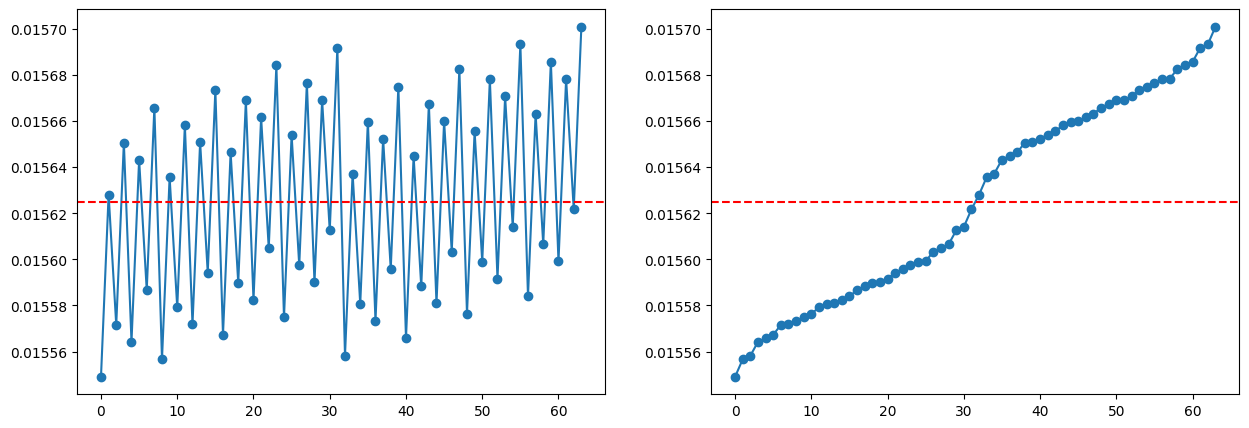

In [73]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(np.abs(result_r)**2, marker='o')
plt.axhline(y=1/(1<<TARGET_QUBIT), color='r', linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(sorted(np.abs(result_r)**2), marker='o')
plt.axhline(y=1/(1<<TARGET_QUBIT), color='r', linestyle='--')
# plt.ylim(0, 1)

In [50]:
idx_gt = np.argmax(np.abs(ground_state))
idx_gt_bin = bin(idx_gt)[2:].zfill(TARGET_QUBIT)

idx_res = np.argmax(np.abs(result_r))
idx_res_min = np.argmin(np.abs(result_r))
idx_res_bin = bin(idx_res)[2:].zfill(TARGET_QUBIT)
idx_res_min_bin = bin(idx_res_min)[2:].zfill(TARGET_QUBIT)

print(f"Ground state significant indices : {idx_gt} ({idx_gt_bin})")
print(f"DB-QITE result significant indices : {idx_res} ({idx_res_bin})")
print(f"DB-QITE result minimal indices : {idx_res_min} ({idx_res_min_bin})")

Ground state significant indices : 63 (111111)
DB-QITE result significant indices : 63 (111111)
DB-QITE result minimal indices : 0 (000000)


In [51]:
print(np.array(result_r)[idx_res])
print(ground_state[idx_gt])
print(np.array(result_r) @ ground_state)

(0.12359947+0.018680096j)
(1+0j)
(0.12359946966171265+0.018680095672607422j)
